# 18 — Kalman Filter Tracking of a Maneuvering Target

**Section:** Perception · **Mirrors MATLAB:** *Object Tracking and Motion Estimation*

We track a 2-D object with a **constant-velocity** Kalman filter using only noisy position measurements.


## Intuition — what's actually going on?

You're watching a target through a noisy camera — say a car going down the highway. Every frame you get a position estimate, but with random measurement noise. If you just plot the measurements, you get a jagged line. You want a *smooth* estimate of where the target is *and* how fast it's moving.

A **Kalman filter** is the optimal way to do this assuming (a) the target follows a known motion model (e.g., constant velocity) and (b) the noise is Gaussian. It maintains a current best-guess state (position + velocity) plus a *covariance* (how uncertain). Every step:

1. **Predict**: project the state forward in time using the motion model. Uncertainty grows.
2. **Update**: when a new measurement arrives, blend it with the prediction in proportion to their respective confidences. Uncertainty shrinks.

The blending weight is the famous **Kalman gain** — it's automatically computed from the covariance and elegantly does the right thing: if my prediction is very certain, ignore noisy measurements; if my measurements are very accurate, weight them heavily.

The notebook shows the filter recovering a smooth trajectory through a sudden maneuver (target changes direction mid-flight). The constant-velocity assumption breaks for a few steps, the filter lags briefly, then catches up.


## Analytical derivation

**State.** $x = [p_x,\ p_y,\ v_x,\ v_y]^T \in \mathbb{R}^4$ — 2-D position and velocity.

**Linear Gaussian model.** Constant-velocity dynamics over $\Delta t$:

$$x_{t+1} \;=\; F x_t + w_t,\qquad w_t \sim \mathcal{N}(0, Q),\qquad F = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

Process noise $Q$ models the deviation from constant velocity — bigger on the velocity components since accelerations can occur unmodeled.

Observation: we measure position only,

$$z_t \;=\; H x_t + v_t,\qquad v_t \sim \mathcal{N}(0, R),\qquad H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

**Kalman filter recursion.** Maintain Gaussian belief $x \sim \mathcal{N}(\hat x, P)$.

*Predict:*

$$\hat x^- \;=\; F \hat x,\qquad P^- \;=\; F P F^T + Q$$

*Update* (given measurement $z$):

$$\text{innovation:}\quad y = z - H \hat x^-$$
$$\text{innovation covariance:}\quad S = H P^- H^T + R$$
$$\text{Kalman gain:}\quad K = P^- H^T S^{-1}$$
$$\hat x \;=\; \hat x^- + K\,y$$
$$P \;=\; (I - K H)\,P^-$$

**Optimality.** Among all linear estimators, the KF minimizes MSE; for Gaussian noise it is also the *minimum-variance* unbiased estimator.

**Handling unmodeled maneuvers.** When the true target suddenly changes velocity (as at $t = 5\,$s in this notebook), the constant-velocity model is wrong for a few steps. Because $Q$ allows for some unmodeled velocity drift, the filter "catches up" — but transient error appears. Increasing $Q$ on the velocity components trades steady-state smoothness for maneuver responsiveness.

### Compatibility check — math ↔ code

| Math | Code |
|---|---|
| State transition $F$ | `F = np.array([[1,0,dt,0],[0,1,0,dt],[0,0,1,0],[0,0,0,1]])` |
| Observation matrix $H$ | `H = np.array([[1,0,0,0],[0,1,0,0]])` |
| Process noise $Q$ | `Q = np.diag([0.01, 0.01, 0.15, 0.15])` |
| Predict $\hat x^- = F \hat x$ | `x_est = F @ x_est` |
| Predict $P^- = F P F^T + Q$ | `P = F @ P @ F.T + Q` |
| Innovation $y = z - H \hat x^-$ | `y = z[k] - H @ x_est` |
| Innovation cov $S = H P H^T + R$ | `S = H @ P @ H.T + R_mat` |
| Kalman gain $K = P H^T S^{-1}$ | `K = P @ H.T @ np.linalg.inv(S)` |
| Update mean | `x_est = x_est + K @ y` |
| Update cov $(I - K H) P$ | `P = (np.eye(4) - K @ H) @ P` |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

T, dt = 100, 0.1
true = np.zeros((T, 4))           # x, y, vx, vy
true[0] = [0, 0, 1, 0.5]
for k in range(1, T):
    true[k] = true[k - 1].copy()
    true[k, :2] += true[k - 1, 2:] * dt
    if k == 50:
        true[k, 2:] = [-0.5, 1.0]   # sudden maneuver

R_obs = 0.5
z = true[:, :2] + np.random.randn(T, 2) * R_obs


In [2]:
F = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])
H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])
Q = np.diag([0.01, 0.01, 0.15, 0.15])
R_mat = np.eye(2) * R_obs ** 2

x_est = np.zeros(4); P = np.eye(4)
est_hist = []
for k in range(T):
    x_est = F @ x_est
    P = F @ P @ F.T + Q
    y = z[k] - H @ x_est
    S = H @ P @ H.T + R_mat
    K = P @ H.T @ np.linalg.inv(S)
    x_est = x_est + K @ y
    P = (np.eye(4) - K @ H) @ P
    est_hist.append(x_est.copy())

est_hist = np.array(est_hist)
rmse = np.sqrt(np.mean((est_hist[:, :2] - true[:, :2]) ** 2))
print(f"Position RMSE: {rmse:.3f} m")


Position RMSE: 0.282 m


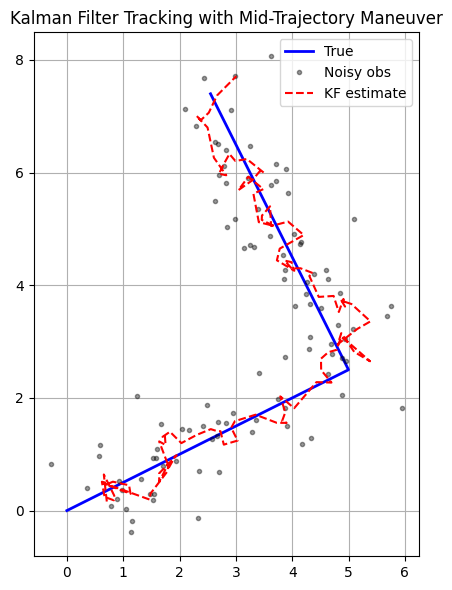

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(true[:, 0], true[:, 1], 'b-', lw=2, label='True')
ax.plot(z[:, 0], z[:, 1], 'k.', alpha=0.4, label='Noisy obs')
ax.plot(est_hist[:, 0], est_hist[:, 1], 'r--', lw=1.5, label='KF estimate')
ax.grid(); ax.legend(); ax.set_aspect('equal')
ax.set_title('Kalman Filter Tracking with Mid-Trajectory Maneuver')
plt.tight_layout()
plt.show()


## References & rigor notes

**Theorem** (Kalman filter optimality; Kalman, 1960). *Among all linear estimators of $x_t$ given measurements $z_{1:t}$ for a linear-Gaussian system, the Kalman filter achieves minimum mean-square error. For Gaussian noise, the KF is the optimal estimator among all (not just linear) functions of $z_{1:t}$.*

**Innovation as whitness test.** When the model is correct, the innovation $\nu_t = z_t - H\hat x_t^-$ is zero-mean white noise with covariance $S_t = HPH^T + R$. Monitoring $\nu^T S^{-1} \nu$ (the normalized innovation squared) is a standard online check for model mis-specification.

**Maneuver handling.** Real targets accelerate, turn, etc. Mitigations:
- **Constant-acceleration** model: extend state to include $a_x, a_y$.
- **Interactive Multiple Model (IMM)**: run several KFs in parallel (CV + CA + coordinated turn), blend by posterior probability — the standard radar-tracking approach.

**Complexity.** $O(n^3)$ per step due to matrix inverses ($n$ = state dim). For $n=4$ here it's microseconds; even $n=20$ is real-time.

**References.**
- Kalman, R. E. (1960). *A new approach to linear filtering and prediction problems*. ASME J. Basic Engineering, 82(D), 35-45.
- Bar-Shalom, Y., Li, X. R., & Kirubarajan, T. (2001). *Estimation with Applications to Tracking and Navigation*. Wiley.
- Blom, H. A. P., & Bar-Shalom, Y. (1988). *The interacting multiple model algorithm for systems with Markovian switching coefficients*. IEEE Trans. Auto. Control, 33(8).
